# Podstawowy Autoenkoder
<hr>

![](./images/auto.png)

Autoenkoder rozumiemy jako sieć neuronową, która na wyjściu ma odtwarzać ten sam obiekt, który dostaje na wejściu. Zazwyczaj na autoenkoder patrzymy jako na połączenie dwóch modeli: enkodera $\mathcal{E}$ i dekodera $\mathcal{D}$. Interpretujemy działanie modelu w następujący sposób: enkoder kompresuje wejściowy przykład $x$ do wektora $y$, o którym myślimy jako o reprezentacji ukrytej. Dekoder na podstawie wektora $y$ produkuje $\hat{x}$, które ma aproksymować oryginalne wejście $x$. Tzn.:

$$
y = \mathcal{E} x 
$$
$$
\hat{x} = \mathcal{D} y
$$

Funkcją kosztu w autoenkoderze będzie MSE pomiędzy wejściem a wyjściem:
$$
\mathcal{L}_{AE} =\frac{1}{n}\sum_i \|x_i-\mathcal{D}\mathcal{E} x_i\|_2^2,
$$
 

Enkoder i dekoder mogą być dowolnymi sieciami neuronowymi, najczęściej jednak dekoder składa się z tych samych transformacji co enkoder w odwrotnej kolejności.  



<hr>

### MNIST
Zacznijmy od przetworzenia zbioru danych, na którym będziemy pracować. Będzie to MNIST, składający się z cyfr pisanych ręcznie od 0 do 9. Składa się on z 60 000 zdjęć do trenowania i 10 000 zdjęć do testowania. 

![](./images/MNIST_dataset_example.png)

In [1]:
from typing import List, Tuple
import functions_Podstawowy_Autoenkoder as fpa
from torch.utils.data import Subset
import numpy as np
import torch
import torchvision
from torch import nn
from torch.optim import SGD
from torchvision.datasets import MNIST
from torchvision.transforms import ToTensor,Lambda,Compose
from sklearn.decomposition import PCA
# Zaczynamy od pobrania zbioru danych 
training_dataset = MNIST(
    root=".",
    download=True,
    train=True,
    transform = Compose([ToTensor(),
                       Lambda(lambda x: x.flatten())])
)
# ToTensor() – konwertuje obrazy z formatu PIL na tensor PyTorch,gdzie wartości pikseli są w zakresie [0.0, 1.0] zamiast [0, 255]
#Lambda(lambda x: x.flatten()) Spłaszcza każdy obraz do jednego wymiaru czyli w naszym przypadku 1*28*28 = 784

image, label = training_dataset[0]
# image jest postaci [C,H,W], gdzie C to kanał kolorów - u nas C jest równe 1, gdyż mamy tutaj doczynienia ze skalą szarości, H to wysokość i W to szerokość
# Zatem dla odpowiednich a i b wartość image[0][a][b] mówi nam jak bardzo intensywna jest szarość odpowiedniego piksela

#Potrzebujemy jeszcze zbioru danych, który posłuży nam do testu modelu
test_dataset = MNIST(
    root=".",
    download=True,
    train=False,
    transform = Compose([ToTensor(),
                       Lambda(lambda x: x.flatten())])
)
batch_size = 128
train_loader = torch.utils.data.DataLoader(dataset=training_dataset, batch_size=batch_size, shuffle=True)

## Zadanie 1.

Należy zaimplementować enkoder i dekoder. Kolejne warstwy w enkoderze mają mieć następującą liczbę neuronów: [784, 128, 128, 64, `latent_dim`]. Analogicznie dekoder ma wyglądać następująco: [`latent_dim`, 64, 128, 128, 784]. Wejście i wyjście mają 784 neurony, jako że taka jest wymiarowość MNIST-a. Wartość `latent_dim` dostajemy na wejściu do konstruktora (`latent_dim`).

Na warstwach ukrytych chcemy mieć aktywacje ReLU, tzn. po każdym połączeniu liniowym stosujemy ReLU, ale **na końcu enkodera nie stosujemy żadnej aktywacji**, na końcu dekodera stosujemy aktywację sigmoidalną.

**Pytanie: Dlaczego na końcu dekodera chcemy mieć sigmoidę?**

In [2]:
class AutoEncoder(torch.nn.Module):
    def __init__(self, latent_dim: int):
        super(AutoEncoder, self).__init__()
        self.latent_dim = latent_dim
        self.encoder = torch.nn.Sequential(
            ...
        )
        self.decoder = torch.nn.Sequential(
            ...
        )
        
    def encode(self, x: torch.Tensor):
        return self.encoder(x)

    def decode(self, encoded: torch.Tensor):
        return self.decoder(encoded)
        
    def forward(self, x: torch.Tensor):
        # encode and decode
        encoded = self.encode(x)
        decoded = self.decode(encoded)
        return encoded, decoded

Epoch: 0  |  train loss: 0.0500


<Figure size 640x480 with 0 Axes>

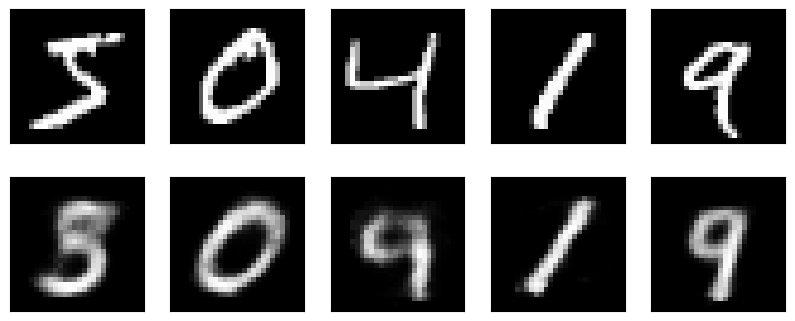

<Figure size 640x480 with 0 Axes>

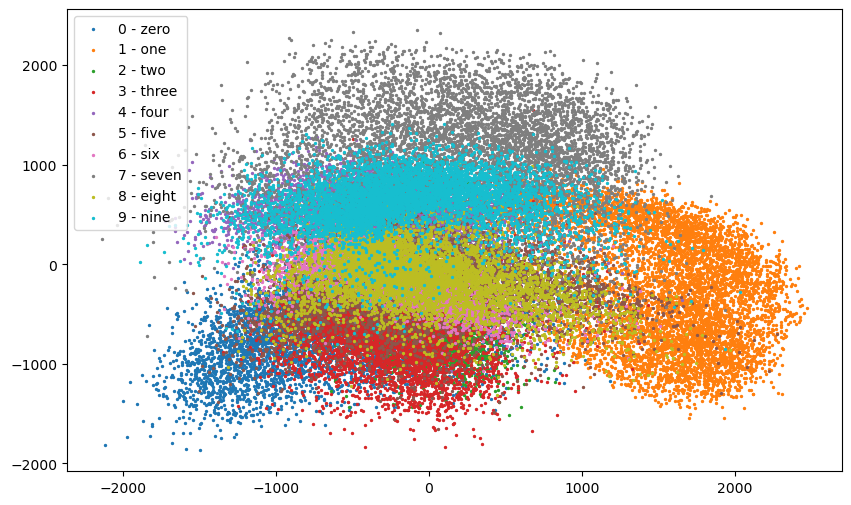

Epoch: 1  |  train loss: 0.0288
Epoch: 2  |  train loss: 0.0234
Epoch: 3  |  train loss: 0.0208
Epoch: 4  |  train loss: 0.0193
Epoch: 5  |  train loss: 0.0183
Epoch: 6  |  train loss: 0.0176
Epoch: 7  |  train loss: 0.0171
Epoch: 8  |  train loss: 0.0167
Epoch: 9  |  train loss: 0.0165
Epoch: 10  |  train loss: 0.0163


<Figure size 640x480 with 0 Axes>

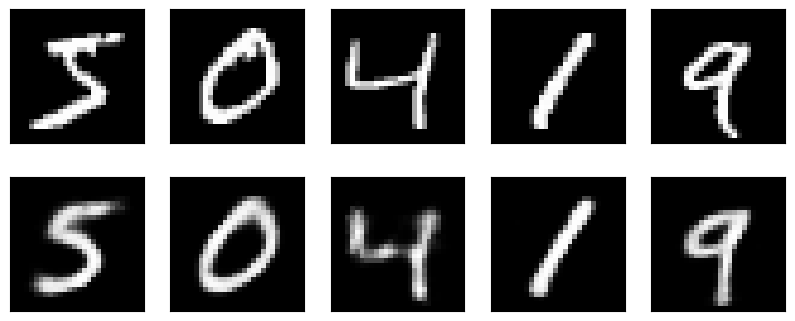

<Figure size 640x480 with 0 Axes>

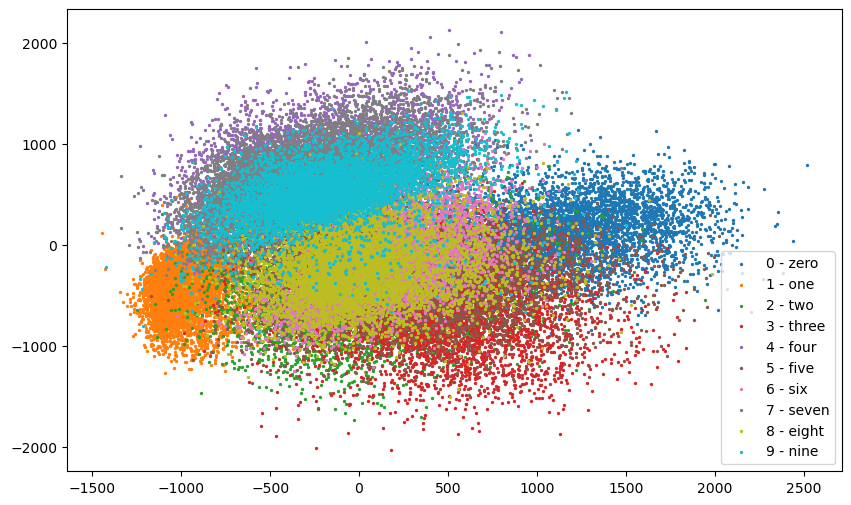

Epoch: 11  |  train loss: 0.0161
Epoch: 12  |  train loss: 0.0160
Epoch: 13  |  train loss: 0.0158
Epoch: 14  |  train loss: 0.0157
Epoch: 15  |  train loss: 0.0155
Epoch: 16  |  train loss: 0.0155
Epoch: 17  |  train loss: 0.0154
Epoch: 18  |  train loss: 0.0152
Epoch: 19  |  train loss: 0.0152
Epoch: 20  |  train loss: 0.0151


<Figure size 640x480 with 0 Axes>

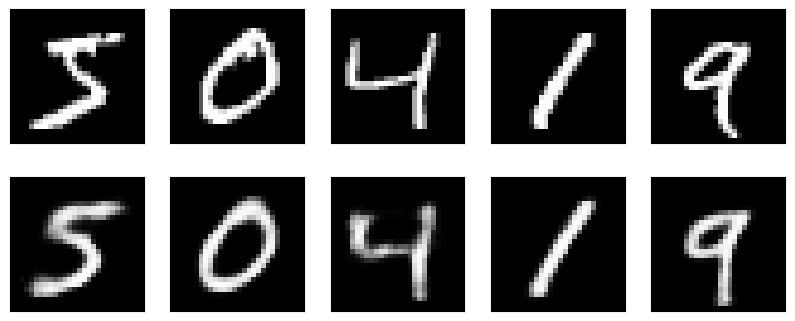

<Figure size 640x480 with 0 Axes>

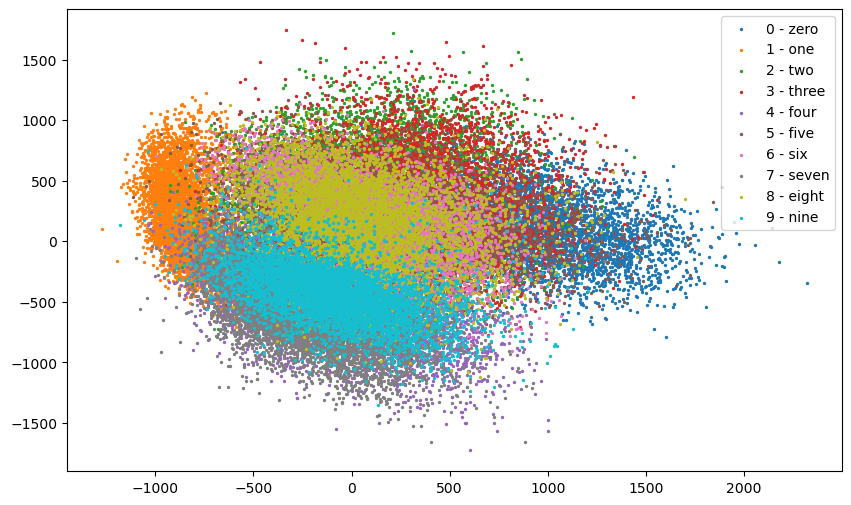

Epoch: 21  |  train loss: 0.0151
Epoch: 22  |  train loss: 0.0150
Epoch: 23  |  train loss: 0.0149
Epoch: 24  |  train loss: 0.0149


In [3]:
# Hyper Parameters
epochs: int = 25
LR: float = 5e-3  # learning rate

# prepare original data for plotting

autoencoder = AutoEncoder(latent_dim=10)

optimizer = torch.optim.Adam(autoencoder.parameters(), lr=LR)
rec_loss_fn = torch.nn.MSELoss()

for epoch in range(epochs):
    epoch_losses = []  # For logging purposes
    for step, (x, y) in enumerate(train_loader):
        x = x
        encoded, decoded = autoencoder(x)
        loss_val = rec_loss_fn(decoded, x)  # calculate loss
        optimizer.zero_grad()  # clear gradients for this training step
        loss_val.backward()  # backpropagation, compute gradients
        optimizer.step()  # apply gradients
        epoch_losses.append(loss_val.item())

    print(f"Epoch: {epoch}  |  train loss: {np.mean(epoch_losses):.4f}")

    if epoch % 10 == 0:
        fpa.plot_dataset(training_dataset, autoencoder)
        fpa.plot_pca(training_dataset, autoencoder)

## Uczenie częściowo nadzorowane

W praktyce zbudowanie w pełni nadzorowanego zbioru danych często jest kosztowne. Jeżeli chcielibyśmy uczyć się klasyfikacji obrazków naturalnych, to zdobycie dużych zbiorów danych nie jest trudne (możemy je zescrapować z internetu), natomiast zdobycie do nich etykiet wymagałoby czasu człowieka, który zidentyfikowałby, co się znajduje na poszczególnych obrazkach. W niektórych przypadkach etykietowanie jest jeszcze bardziej kosztowne - w zagadnieniu segmentacji, gdzie chcemy każdemu pikselowi w obrazku przypisać jedną klasę, zapisanie etykiety dla jednego obrazka może zająć ekspertowi kilka godzin.

Problem liczby etykiet i ich jakości jest w praktyce bardzo istotny. Dlatego też w praktyce chcielibyśmy mieć metody głębokiego uczenia, które potrafią wykorzystać dane, dla których nie mamy etykiet. W poniższym przykładzie zbudujemy prosty model częściowo nadzorowany z wykorzystaniem autoenkodera.

## Zadanie 2. Uczenie częściowo nadzorowane

Załóżmy, że z 60.000 przykładów zbiorze MNIST tylko 100 przykładów ma podaną etykietę, a dla pozostałych 59.900 nie mamy etykiety - tym samym mamy problem uczenia częściowo nadzorowanego. Nasze 100 przykładów z etykietami zdefiniowane są w zmiennej `labeled_data`.

1. Uruchom prostą sieć neuronową (klasyfikator), która uczy się wyłącznie bezpośrednio na 100 podanych przykładach. Zobacz jaki osiąga wynik na zbiorze testowym.
2. Zaimplementuj i wytrenuj sieć neuronową (klasyfikator) o podobnej architekturze co w poprzednim punkcie, również na datasecie 100 przykładów, ale tym razem niech wejściem do sieci będzie ukryta reprezentacja $y = \mathcal{E}x$ stworzona przez autoenkoder wytrenowany w Zadaniu 1. Zapisz wynik.
3. Porównaj wyniki obu modeli. Wskaż, który nauczył się lepiej i podaj hipotezę dlaczego.


In [4]:
labeled_data = Subset(training_dataset, range(100))
labeled_loader = torch.utils.data.DataLoader(dataset=labeled_data, batch_size=32, shuffle=True)
test_loader = torch.utils.data.DataLoader(dataset=test_dataset, batch_size=5000, shuffle=True)

In [5]:
### Model baseline'owy - klasyfikator
class Model(torch.nn.Module):
    def __init__(self):
        super().__init__()
        self.base = torch.nn.Sequential(
            torch.nn.Linear(784,32),
            torch.nn.ReLU(),
            torch.nn.Linear(32,64),
            torch.nn.ReLU(),
            torch.nn.Linear(64,128),
            torch.nn.ReLU(),
            torch.nn.Linear(128,10),
        )
    def forward(self,x):
        return self.base(x)

model = Model()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
criterion = torch.nn.CrossEntropyLoss()
for epoch in range(25):
    epoch_losses = []  # For logging purposes
    for step, (x, y) in enumerate(labeled_loader):
        optimizer.zero_grad()  # clear gradients for this training step
        output = model(x)
        loss_val = criterion(output,y)
        loss_val.backward()  # backpropagation, compute gradients
        optimizer.step()  # apply gradients
        epoch_losses.append(loss_val.item())

    print(f"Epoch: {epoch}  |  train loss: {np.mean(epoch_losses):.4f}")

with torch.no_grad():
    correct: int = 0
    for i, (x, y) in enumerate(test_loader):
        output = model(x)
        A = torch.argmax(output,dim=1)
        B = A[A == y]
        correct += len(B)
    print(f'Test accuracy: {(100*correct) / len(test_dataset)}%')

Epoch: 0  |  train loss: 2.2990
Epoch: 1  |  train loss: 2.2688
Epoch: 2  |  train loss: 2.2525
Epoch: 3  |  train loss: 2.2133
Epoch: 4  |  train loss: 2.1720
Epoch: 5  |  train loss: 2.0394
Epoch: 6  |  train loss: 2.0764
Epoch: 7  |  train loss: 1.8844
Epoch: 8  |  train loss: 1.7516
Epoch: 9  |  train loss: 1.5411
Epoch: 10  |  train loss: 1.3635
Epoch: 11  |  train loss: 1.2141
Epoch: 12  |  train loss: 1.0818
Epoch: 13  |  train loss: 1.1164
Epoch: 14  |  train loss: 0.9531
Epoch: 15  |  train loss: 0.9897
Epoch: 16  |  train loss: 0.7021
Epoch: 17  |  train loss: 0.6026
Epoch: 18  |  train loss: 0.6172
Epoch: 19  |  train loss: 0.4672
Epoch: 20  |  train loss: 0.4694
Epoch: 21  |  train loss: 0.2802
Epoch: 22  |  train loss: 0.2436
Epoch: 23  |  train loss: 0.2255
Epoch: 24  |  train loss: 0.1673
Test accuracy: 62.24%


In [6]:
### Tutaj zaimplementuj i wytrenuj klasyfikator oparty o reprezentację podaną przez autoenkoder.
class Klasyfikator(torch.nn.Module):
   ...

Epoch: 0  |  train loss: 2.2915
Epoch: 1  |  train loss: 2.2508
Epoch: 2  |  train loss: 2.2106
Epoch: 3  |  train loss: 2.1182
Epoch: 4  |  train loss: 2.0289
Epoch: 5  |  train loss: 1.7020
Epoch: 6  |  train loss: 1.6522
Epoch: 7  |  train loss: 1.4538
Epoch: 8  |  train loss: 1.2147
Epoch: 9  |  train loss: 1.1492
Epoch: 10  |  train loss: 0.7970
Epoch: 11  |  train loss: 0.6315
Epoch: 12  |  train loss: 0.4824
Epoch: 13  |  train loss: 0.4766
Epoch: 14  |  train loss: 0.3314
Epoch: 15  |  train loss: 0.2842
Epoch: 16  |  train loss: 0.2130
Epoch: 17  |  train loss: 0.1515
Epoch: 18  |  train loss: 0.1085
Epoch: 19  |  train loss: 0.0606
Epoch: 20  |  train loss: 0.0499
Epoch: 21  |  train loss: 0.0307
Epoch: 22  |  train loss: 0.0232
Epoch: 23  |  train loss: 0.0161
Epoch: 24  |  train loss: 0.0121
Test accuracy: 72.44 %
